In [18]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors
import copy
%matplotlib inline

In [19]:
# Heuristic function: Euclidean distance
def heuristic(a, b):
    return ((a[0] - b[0])**2 + (a[1] - b[1])**2)**0.5

# A* algorithm
def a_star(grid, row, col, row1, col1):
    start = (row, col)
    end = (row1, col1)
    rows, cols = len(grid), len(grid[0])
    
    open_set = []
    heapq.heappush(open_set, (0, start))  # (priority, node)
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, end)}
    visited = [[False for _ in range(cols)] for _ in range(rows)]
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == end:
            break
        
        x, y = current
        visited[x][y] = True
        
        # Explore neighbors (allowing diagonal movements)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (1, 1), (-1, 1), (1, -1)]:
            neighbor = (x + dx, y + dy)
            if 0 <= neighbor[0] < rows and 0 <= neighbor[1] < cols and grid[neighbor[0]][neighbor[1]] == 0:
                tentative_g_score = g_score[current] + heuristic(current, neighbor)
                if tentative_g_score < g_score.get(neighbor, float('inf')):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + heuristic(neighbor, end)
                    if neighbor not in [n[1] for n in open_set]:
                        heapq.heappush(open_set, (f_score[neighbor], neighbor))
    
    # Reconstruct path
    path = []
    current = end
    while current in came_from:
        path.append(current)
        current = came_from[current]
    
    path.reverse()
    return g_score.get(end, float('inf')), path, visited

In [20]:
def save_animation_video(grid, start_x, start_y, end_x, end_y):
    cp = copy.deepcopy(grid)
    dist, path, visited = a_star(grid, start_x, start_y, end_x, end_y)  # Use A* algorithm
    m,n = path[0]
    cp[m][n] = 3
    # Print the shortest path distance
    print(f"Shortest path distance: {dist}")
    
    # Initialize the figure and color map
    fig = plt.figure(figsize=(10, 10))
    cmap = matplotlib.colors.ListedColormap(["white", "black", "lightgreen", "red"])
    fps = 50
    skip_factor = 10
    plt.imshow(grid, cmap=cmap)
    grid1 = []

    # First, add the explored nodes to the grid
    for i in range(len(visited)):
        for j in range(len(visited[0])):
            if visited[i][j]:
                cp[i][j] = 2  # Mark explored nodes as light green
                m = copy.deepcopy(cp)
                grid1.append(m)

    # Now, add the path to the grid
    for x, y in path:
        cp[x][y] = 3  # Mark path as red
        m = copy.deepcopy(cp)
        grid1.append(m)

    # Show the first frame
    im = plt.imshow(grid1[0], cmap=cmap)

    # Animation function
    def animate_func(i):
        if i % fps ==0:
            print('.', end=' ')
        idx = i * skip_factor
        if idx < len(grid1):
            im.set_array(grid1[idx])
        return [im]

    # Create and save the animation
    anim = animation.FuncAnimation(fig, animate_func, frames=len(grid1), interval=100)
    anim.save('a_star_animation.gif', writer="pillow")  # Save as A* animation video
    print("End")


In [21]:
grid20 = np.loadtxt(r"grids\grid15.txt", dtype= int)
grid20 = grid20.tolist()

Shortest path distance: 58.0832611206852
. . . . . . . . . . End


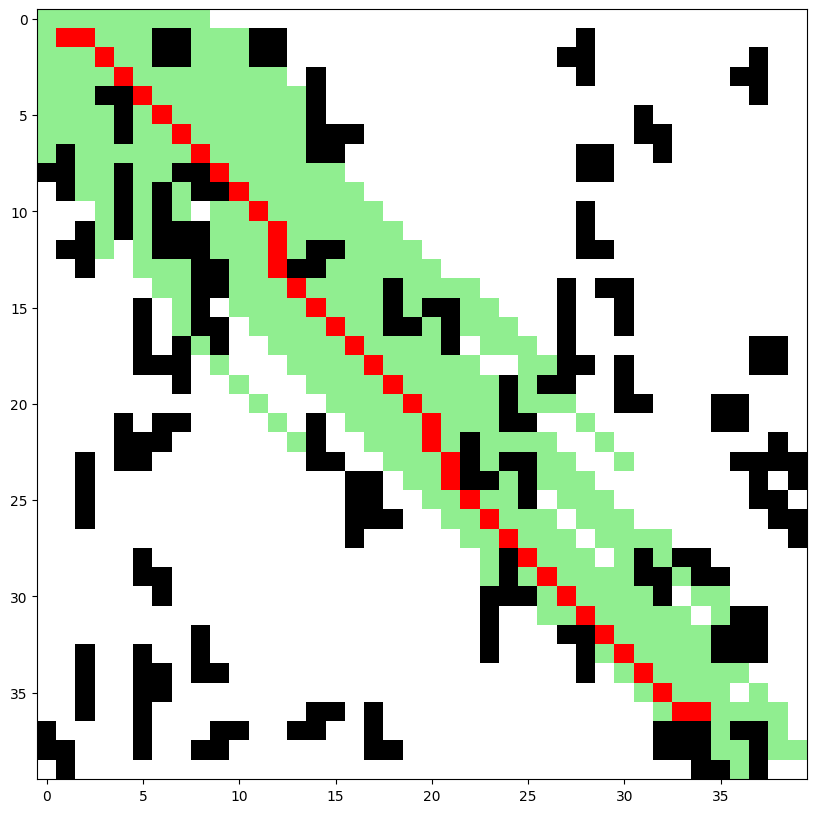

In [22]:
save_animation_video(grid20,0,0,39,39)